In [1]:
from brian2 import *
import numpy as np
import matplotlib.pyplot as plt
from __future__ import division, print_function
import numpy as np
from scipy.signal import butter, filtfilt, welch


In [2]:
np.random.seed(377)

start_scope()
delta_t = 0.1
sim_length = 30000
defaultclock.dt = delta_t * ms
### neuron model parameters ###
C = 200 * pF
g_leak = 10 * nS
tau = 20 * ms
V_rest = -60 * mV
reversal_P = 0 * mV
reversal_B = -70 * mV
reversal_A = -70 * mV
V_th = -50 * mV
V_reset = -60 * mV

### synapse parameters ###
synaptic_delay = 1 * ms

tau_syn_P = 2 * ms
tau_syn_A = 4 * ms
tau_syn_B = 1.5 * ms

tau_D = 250 * ms
eta_D = 0.18
e_AB = 0.5

# synapric conductance increases and connection probabilities
g_PP = 0.2 * nS
p_PP = 0.01

g_PA = 6 * nS
p_PA = 0.6

g_PB = 0.7 * nS
p_PB = 0.5

g_AP = 0.2 * nS
p_AP = 0.01

g_AA = 4 * nS
p_AA = 0.6

g_AB = 8 * nS
p_AB = 0.2

g_BP = 0.05 * nS
p_BP = 0.2

g_BA = 7 * nS
p_BA = 0.6

g_BB = 5 * nS
p_BB = 0.2

# population sizes
N_P = 8200
N_B = 135
N_A = 50

### currents ###
I_BG = 200 * pA

# I_ext = I_BG + I_i


### equations ###
eqs = '''
I_ext : amp (shared)
dv/dt = (g_leak*(V_rest - v) - (g_P*(v-reversal_P) + g_A*(v-reversal_A) + g_B*(v-reversal_B)) + I_ext)/C : volt (unless refractory)
dg_P/dt = -g_P/tau_syn_P : siemens
dg_A/dt = -g_A/tau_syn_A : siemens
dg_B/dt = -g_B/tau_syn_B : siemens
I_syn_B = g_B*(v - reversal_B) : amp
'''


@network_operation(dt=delta_t * ms, when='start')
def current_pulse():
    if 1500 * ms <= defaultclock.t <= 1510 * ms:
        group_B[0:99].I_ext = np.random.uniform(0, 700) * pA
    else:
        group_B.I_ext = 200 * pA
        group_A.I_ext = 200 * pA
        group_P.I_ext = 200 * pA


#d -
### neurons groups ###
group_P = NeuronGroup(N_P, eqs, threshold='v>=V_th', reset='v=V_reset', refractory=1 * ms, method='euler')
group_A = NeuronGroup(N_A, eqs, threshold='v>=V_th', reset='v=V_reset', refractory=1 * ms, method='euler')
group_B = NeuronGroup(N_B, eqs, threshold='v>=V_th', reset='v=V_reset', refractory=1 * ms, method='euler')

### synapses ###
synapse_PP = Synapses(group_P, group_P, on_pre='g_P_post += g_PP', delay=synaptic_delay)
synapse_PP.connect(p=p_PP)

synapse_AP = Synapses(group_P, group_A, on_pre='g_P_post += g_AP', delay=synaptic_delay)
synapse_AP.connect(p=p_AP)

synapse_BP = Synapses(group_P, group_B, on_pre='g_P_post += g_BP', delay=synaptic_delay)
synapse_BP.connect(p=p_BP)

synapse_AA = Synapses(group_A, group_A, on_pre='g_A_post += g_AA', delay=synaptic_delay)
synapse_AA.connect(p=p_AA)

synapse_PA = Synapses(group_A, group_P, on_pre='g_A_post += g_PA', delay=synaptic_delay)
synapse_PA.connect(p=p_PA)

synapse_BA = Synapses(group_A, group_B, on_pre='g_A_post += g_BA', delay=synaptic_delay)
synapse_BA.connect(p=p_BA)

synapse_BB = Synapses(group_B, group_B, on_pre='g_B_post += g_BB', delay=synaptic_delay)
synapse_BB.connect(p=p_BB)

# to control depression
clamp_depr = 1
eqs_std_AB = '''
       g_ab : 1
       de_AB / dt = clamp_depr * (1. - e_AB) / tau_D : 1 (clock-driven)
       '''

synapse_AB = Synapses(group_B, group_A, model=eqs_std_AB, on_pre='''
                    g_B_post += g_AB*e_AB
                    e_AB = clip(e_AB - e_AB * eta_D, 0, 1)
                      ''', method='exact', delay=synaptic_delay)
synapse_AB.connect(p=p_AB)

synapse_PB = Synapses(group_B, group_P, on_pre='g_B_post += g_PB', delay=synaptic_delay)
synapse_PB.connect(p=p_PB)

group_P.v = V_rest
group_B.v = V_rest
group_A.v = V_rest + (V_th - V_rest) * np.random.rand(N_A)

# Initialize synaptic conductances with small random values
group_P.g_P = 0.01 * nS * np.random.rand(N_P)
group_A.g_A = 0.01 * nS * np.random.rand(N_A)
group_B.g_B = 0.01 * nS * np.random.rand(N_B)

# Add PopulationRateMonitors
#pop_rate_P = PopulationRateMonitor(group_P)
#pop_rate_A = PopulationRateMonitor(group_A)
#pop_rate_B = PopulationRateMonitor(group_B)

current_monitor = StateMonitor(group_P[0:200], 'I_syn_B', record=True)

#statemon = StateMonitor(group_B, 'I_ext', record=True)
#eventmon = EventMonitor(group_B, ('pulse_on', 'I_i'), record=True)
network = Network(collect())

# Run the simulation
network.run(sim_length * ms)

WARNING    'e_AB' is an internal variable of group 'synapses_7', but also exists in the run namespace with the value 0.5. The internal variable will be used. [brian2.groups.group.Group.resolve.resolution_conflict]


In [3]:
"""Detect peaks in data based on their amplitude and other features."""

__author__ = "Marcos Duarte, https://github.com/demotu/BMC"
__version__ = "1.0.4"
__license__ = "MIT"


def detect_peaks(x, mph=None, mpd=1, threshold=0, edge='rising',
                 kpsh=False, valley=False, show=False, ax=None):
    """Detect peaks in data based on their amplitude and other features.
    Parameters
    ----------
    x : 1D array_like
        data.
    mph : {None, number}, optional (default = None)
        detect peaks that are greater than minimum peak height.
    mpd : positive integer, optional (default = 1)
        detect peaks that are at least separated by minimum peak distance (in
        number of data).
    threshold : positive number, optional (default = 0)
        detect peaks (valleys) that are greater (smaller) than `threshold`
        in relation to their immediate neighbors.
    edge : {None, 'rising', 'falling', 'both'}, optional (default = 'rising')
        for a flat peak, keep only the rising edge ('rising'), only the
        falling edge ('falling'), both edges ('both'), or don't detect a
        flat peak (None).
    kpsh : bool, optional (default = False)
        keep peaks with same height even if they are closer than `mpd`.
    valley : bool, optional (default = False)
        if True (1), detect valleys (local minima) instead of peaks.
    show : bool, optional (default = False)
        if True (1), plot data in matplotlib figure.
    ax : a matplotlib.axes.Axes instance, optional (default = None).
    Returns
    -------
    ind : 1D array_like
        indeces of the peaks in `x`.
    Notes
    -----
    The detection of valleys instead of peaks is performed internally by simply
    negating the data: `ind_valleys = detect_peaks(-x)`

    The function can handle NaN's
    See this IPython Notebook [1]_.
    References
    ----------
    .. [1] http://nbviewer.ipython.org/github/demotu/BMC/blob/master/notebooks/DetectPeaks.ipynb
    Examples
    --------
    # >>> from detect_peaks import detect_peaks
    # >>> x = np.random.randn(100)
    # >>> x[60:81] = np.nan
    # >>> # detect all peaks and plot data
    # >>> ind = detect_peaks(x, show=True)
    # >>> print(ind)
    # >>> x = np.sin(2*np.pi*5*np.linspace(0, 1, 200)) + np.random.randn(200)/5
    # >>> # set minimum peak height = 0 and minimum peak distance = 20
    # >>> detect_peaks(x, mph=0, mpd=20, show=True)
    # >>> x = [0, 1, 0, 2, 0, 3, 0, 2, 0, 1, 0]
    # >>> # set minimum peak distance = 2
    # >>> detect_peaks(x, mpd=2, show=True)
    # >>> x = np.sin(2*np.pi*5*np.linspace(0, 1, 200)) + np.random.randn(200)/5
    # >>> # detection of valleys instead of peaks
    # >>> detect_peaks(x, mph=0, mpd=20, valley=True, show=True)
    # >>> x = [0, 1, 1, 0, 1, 1, 0]
    # >>> # detect both edges
    # >>> detect_peaks(x, edge='both', show=True)
    # >>> x = [-2, 1, -2, 2, 1, 1, 3, 0]
    # >>> # set threshold = 2
    # >>> detect_peaks(x, threshold = 2, show=True)
    """

    x = np.atleast_1d(x).astype('float64')
    if x.size < 3:
        return np.array([], dtype=int)
    if valley:
        x = -x
    # find indexes of all peaks
    dx = x[1:] - x[:-1]
    # handle NaN's
    indnan = np.where(np.isnan(x))[0]
    if indnan.size:
        x[indnan] = np.inf
        dx[np.where(np.isnan(dx))[0]] = np.inf
    ine, ire, ife = np.array([[], [], []], dtype=int)
    if not edge:
        ine = np.where((np.hstack((dx, 0)) < 0) & (np.hstack((0, dx)) > 0))[0]
    else:
        if edge.lower() in ['rising', 'both']:
            ire = np.where((np.hstack((dx, 0)) <= 0) & (np.hstack((0, dx)) > 0))[0]
        if edge.lower() in ['falling', 'both']:
            ife = np.where((np.hstack((dx, 0)) < 0) & (np.hstack((0, dx)) >= 0))[0]
    ind = np.unique(np.hstack((ine, ire, ife)))
    # handle NaN's
    if ind.size and indnan.size:
        # NaN's and values close to NaN's cannot be peaks
        ind = ind[np.in1d(ind, np.unique(np.hstack((indnan, indnan - 1, indnan + 1))), invert=True)]
    # first and last values of x cannot be peaks
    if ind.size and ind[0] == 0:
        ind = ind[1:]
    if ind.size and ind[-1] == x.size - 1:
        ind = ind[:-1]
    # remove peaks < minimum peak height
    if ind.size and mph is not None:
        ind = ind[x[ind] >= mph]
    # remove peaks - neighbors < threshold
    if ind.size and threshold > 0:
        dx = np.min(np.vstack([x[ind] - x[ind - 1], x[ind] - x[ind + 1]]), axis=0)
        ind = np.delete(ind, np.where(dx < threshold)[0])
    # detect small peaks closer than minimum peak distance
    if ind.size and mpd > 1:
        ind = ind[np.argsort(x[ind])][::-1]  # sort ind by peak height
        idel = np.zeros(ind.size, dtype=bool)
        for i in range(ind.size):
            if not idel[i]:
                # keep peaks with the same height if kpsh is True
                idel = idel | (ind >= ind[i] - mpd) & (ind <= ind[i] + mpd) \
                       & (x[ind[i]] > x[ind] if kpsh else True)
                idel[i] = 0  # Keep current peak
        # remove the small peaks and sort back the indexes by their occurrence
        ind = np.sort(ind[~idel])

    if show:
        if indnan.size:
            x[indnan] = np.nan
        if valley:
            x = -x
        _plot(x, mph, mpd, threshold, edge, valley, ax, ind)

    return ind


def _plot(x, mph, mpd, threshold, edge, valley, ax, ind):
    """Plot results of the detect_peaks function, see its help."""
    try:
        import matplotlib.pyplot as plt
    except ImportError:
        print('matplotlib is not available.')
    else:
        if ax is None:
            _, ax = plt.subplots(1, 1, figsize=(8, 4))

        ax.plot(x, 'b', lw=1)
        if ind.size:
            label = 'valley' if valley else 'peak'
            label = label + 's' if ind.size > 1 else label
            ax.plot(ind, x[ind], '+', mfc=None, mec='r', mew=2, ms=8,
                    label='%d %s' % (ind.size, label))
            ax.legend(loc='best', framealpha=.5, numpoints=1)
        ax.set_xlim(-.02 * x.size, x.size * 1.02 - 1)
        ymin, ymax = x[np.isfinite(x)].min(), x[np.isfinite(x)].max()
        yrange = ymax - ymin if ymax > ymin else 1
        ax.set_ylim(ymin - 0.1 * yrange, ymax + 0.1 * yrange)
        ax.set_xlabel('Data #', fontsize=14)
        ax.set_ylabel('Amplitude', fontsize=14)
        mode = 'Valley detection' if valley else 'Peak detection'
        ax.set_title("%s (mph=%s, mpd=%d, threshold=%s, edge='%s')"
                     % (mode, str(mph), mpd, str(threshold), edge))

In [4]:
# The method create_butter_bandpass creates a Butterworth digital filter with specified parameters.
# This filter can then be applied to signals for band-pass, low-pass.
averaged = -np.average(current_monitor.I_syn_B, axis=0)


def create_butter_bandpass(lowcut, highcut, fs, order=2, btype='band'):
    """create a butterworth digital filter with given order"""
    # normalize freq with Nyquist freq (to be in [0,1])
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    if btype == 'band':
        b, a = butter(order, [low, high], btype=btype, analog=False)
    elif btype == 'low':
        b, a = butter(order, high, btype=btype, analog=False)
    else:
        b = 0
        a = 0
    return b, a  # a and b are coefficient filter


b_band, a_band = create_butter_bandpass(90, 180, 1e4, 2, btype="band")
band_pass = filtfilt(b_band, a_band, -averaged)

b_low, a_low = create_butter_bandpass(0, 5, 1e4, 2, btype="low")
low_pass = filtfilt(b_low, a_low, -averaged)

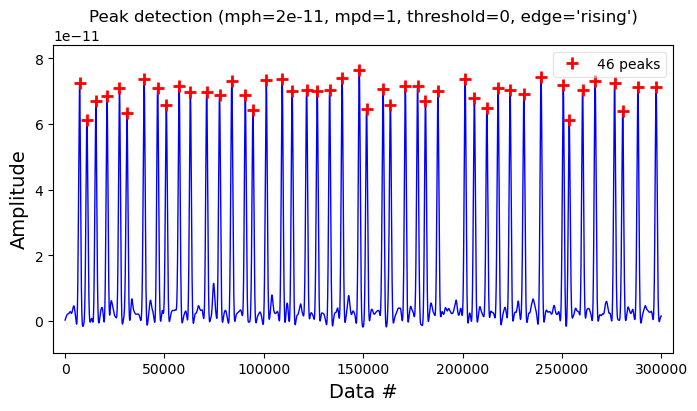

In [5]:
indx = detect_peaks(low_pass, mph=2e-11, mpd=1, threshold=0, edge='rising', valley=False, show=True)
#print('index:', indx)
peaks = low_pass[indx]
#print('peaks', peaks)

In [6]:
def find_onset(seq, peaks, indices, baseline_window_low, baseline_window_high, dt):
    """Find the onset of a sequence of data relative to a set of peaks"""
    baselines = []
    for peak_index in indices:
        # find the baseline
        baseline_start = max(0, int(peak_index - baseline_window_low / dt))
        baseline_end = int(peak_index - baseline_window_high / dt)
        mean_baseline = np.average(seq[baseline_start:baseline_end])
        baselines.append(mean_baseline)
    global_baseline = np.mean(baselines)

    # fwhm = [seq[seq > np.mean(p, global_baseline)] for p in peaks]
    points = []
    for idx, peak in enumerate(peaks):
        fwhm = np.mean([peak, global_baseline])
        local_seq = seq[indices[idx] - int(100 / dt):indices[idx]]
        fwhm_point = seq[np.where(local_seq > fwhm)][0]
        #fwhm_point = indices[idx] - int(100 / dt) + np.where(local_seq > fwhm)[0]
        points.append(fwhm_point)
    return points


onset_points = find_onset(low_pass, peaks, indx, 200, 100, delta_t)

In [7]:
def find_onset(seq, peaks, indices, baseline_window_low, baseline_window_high, dt):
    baselines = []
    for peak_index in indices:
        baseline_start = max(0, int(peak_index - baseline_window_low / dt))
        baseline_end = max(0, int(peak_index - baseline_window_high / dt))
        mean_baseline = np.average(seq[baseline_start:baseline_end])
        baselines.append(mean_baseline)

    global_baseline = np.mean(baselines)

    points = []
    for idx, peak in enumerate(peaks):
        fwhm = np.mean([peak, global_baseline])

        # Search within a 100 ms window before the peak
        start_idx = int(indices[idx] - 100 / dt)
        local_seq = seq[start_idx:indices[idx]]

        # Find the first point where the signal exceeds the half maximum
        try:
            onset_point = start_idx + int(np.where(local_seq > fwhm)[0][0])
            points.append(onset_point)
        except IndexError:
            print(f"Onset not found for peak at index {indices[idx]}")
            points.append(None)

    return points


onset_points = find_onset(low_pass, peaks, indx, 200, 100, delta_t)

In [8]:
def find_start_and_end(seq, peak_index, half_max):
  
    start_idx = peak_index
    while start_idx > 0 and seq[start_idx] > half_max:
        start_idx -= 1

    end_idx = peak_index
    while end_idx < len(seq) and seq[end_idx] > half_max:
        end_idx += 1

    return start_idx, end_idx

In [9]:
def find_event_boundaries(seq, peaks, indices, baseline_window_low, baseline_window_high, dt):
    baselines = []
    for peak_index in indices:
        baseline_start = max(0, int(peak_index - baseline_window_low / dt))
        baseline_end = max(0, int(peak_index - baseline_window_high / dt))
        mean_baseline = np.average(seq[baseline_start:baseline_end])
        baselines.append(mean_baseline)

    global_baseline = np.mean(baselines)

    event_boundaries = []
    for idx, peak in enumerate(peaks):
        fwhm = np.mean([peak, global_baseline])
        start_idx = indices[idx]
        while start_idx > 0 and seq[start_idx] > fwhm:
            start_idx -= 1

        end_idx = indices[idx]
        while end_idx < len(seq) and seq[end_idx] > fwhm:
            end_idx += 1
        event_boundaries.append((start_idx, end_idx))
    return event_boundaries
event_boundaries = find_event_boundaries(low_pass, peaks, indx, 200, 100, delta_t)
#print(event_boundaries)




plt.figure(figsize=(12, 6))
plt.plot(current_monitor.t / ms, low_pass / amp, label='Low-Pass Filtered Signal', color='blue')

plt.scatter(current_monitor.t[indx] / ms, low_pass[indx] / amp, color='red', label='SWR Peaks', zorder=3)
plt.scatter([current_monitor.t[start] / ms for start, end in event_boundaries],
            [low_pass[start] / amp for start, end in event_boundaries],
            color='green', label='Start of Event', zorder=3)
plt.scatter([current_monitor.t[end] / ms for start, end in event_boundaries],
            [low_pass[end] / amp for start, end in event_boundaries],
            color='black', label='End of Event', zorder=3)

plt.xlabel('Time (ms)')
plt.ylabel('Amplitude (A)')
plt.title('Low-Pass Filtered Signal with SWR Event Boundaries')
plt.legend(loc='upper right')
plt.grid(True)
plt.show()



[(np.int64(6751), np.int64(7833)), (np.int64(10442), np.int64(11537)), (np.int64(14937), np.int64(15992)), (np.int64(20569), np.int64(21640)), (np.int64(26843), np.int64(27913)), (np.int64(30587), np.int64(31679)), (np.int64(39235), np.int64(40335)), (np.int64(46048), np.int64(47138)), (np.int64(50407), np.int64(51503)), (np.int64(56850), np.int64(57954)), (np.int64(62509), np.int64(63603)), (np.int64(70711), np.int64(71802)), (np.int64(77189), np.int64(78265)), (np.int64(83312), np.int64(84457)), (np.int64(90161), np.int64(91234)), (np.int64(94000), np.int64(95069)), (np.int64(100694), np.int64(101793)), (np.int64(108718), np.int64(109803)), (np.int64(113727), np.int64(114807)), (np.int64(121004), np.int64(122096)), (np.int64(126330), np.int64(127411)), (np.int64(132593), np.int64(133662)), (np.int64(138870), np.int64(139964)), (np.int64(147492), np.int64(148600)), (np.int64(151191), np.int64(152272)), (np.int64(159474), np.int64(160571)), (np.int64(163120), np.int64(164259)), (np.int

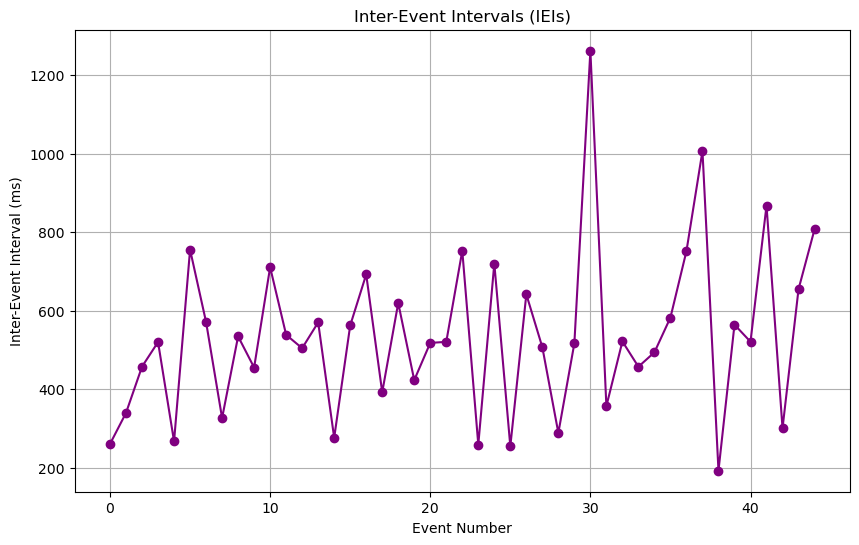

In [10]:
filtered_events = []
print(event_boundaries)
print(len(event_boundaries))
for i in range(len(event_boundaries) - 1):
    start, end = event_boundaries[i]
    next_start, _ = event_boundaries[i + 1]

    # Filter conditions
   # if low_pass[indx[i]] >= 30e-12 and (current_monitor.t[next_start] - current_monitor.t[end]) / ms > 100:
       # filtered_events.append((start, end, indx[i]))

inter_event_intervals = []
#for i in range(len(filtered_events) - 1):
for i in range(len(event_boundaries) - 1):  #TODO:SHK filtered_events
    current_end = event_boundaries[i][1]    #TODO:SHK filtered_events
    next_start = event_boundaries[i + 1][0] #TODO:SHK filtered_events
    iei = (current_monitor.t[next_start] - current_monitor.t[current_end]) / ms  # IEI in ms
    inter_event_intervals.append(iei)

plt.figure(figsize=(10, 6))
plt.plot(range(len(inter_event_intervals)), inter_event_intervals, marker='o', color='purple')
plt.xlabel('Event Number')
plt.ylabel('Inter-Event Interval (ms)')
plt.title('Inter-Event Intervals (IEIs)')
plt.grid(True)
plt.show()

#print("Inter-Event Intervals (IEIs):")
#for i, iei in enumerate(inter_event_intervals):
#    print(f"Event {i + 1}: {iei:.2f} ms")

In [11]:
durations = []
for event in event_boundaries:
    event_duration = event[1] - event[0]
    durations.append(event_duration * defaultclock.dt / ms)

print("Average event duration: {:.2f} ms".format(np.mean(durations)))

incidence = len(event_boundaries) / sim_length * 1000
print(f"Incidence: {incidence:.2f} events/s")

Average event duration: 109.05 ms
Incidence: 1.53 events/s


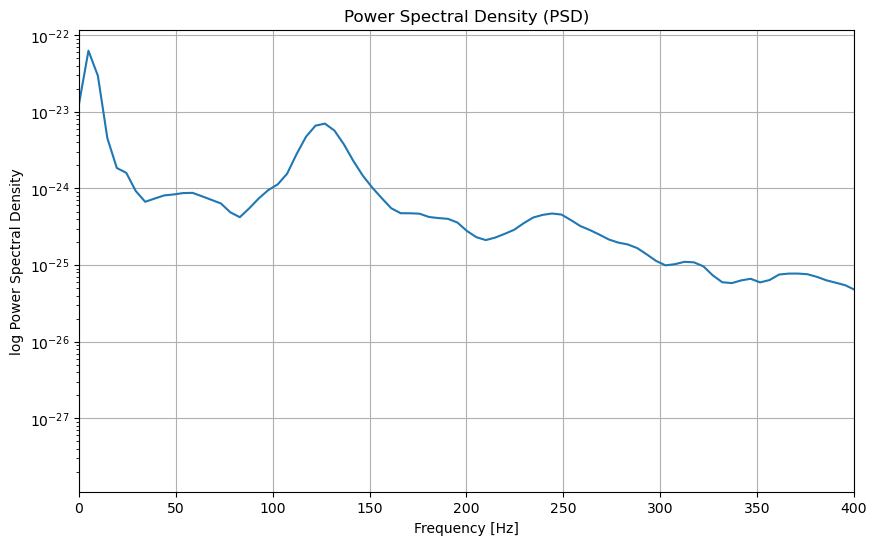

In [22]:
fs = 1000  # Sampling frequency (Hz)
#signal = pop_rate_P.smooth_rate(window="gaussian", width=0.1 * ms) / Hz #current_monitor.I_syn_B[0]
signal = current_monitor.I_syn_B
event_slices = [averaged[start:end] for start, end in event_boundaries]

#signal = -1 * np.concatenate(event_slices)
#Calculate PSD using Welch's method
frequencies, power_spectrum = welch(-averaged, fs = 10000, nperseg=2048, scaling='density')

# Plot the PSD
plt.figure(figsize=(10, 6))
plt.semilogy(frequencies, power_spectrum)
plt.xlabel('Frequency [Hz]')
plt.xlim(0,400)
plt.ylabel('log Power Spectral Density')
plt.title('Power Spectral Density (PSD)')
plt.grid(True)
plt.show()



#event_current = averaged[]
N = len(signal)
freqs = np.fft.fftfreq(N, d=1/fs) 
fft_vals = np.fft.fft(signal)
power_spectrum = np.abs(fft_vals) ** 2  
# Consider only positive frequencies
positive_freqs = freqs[:N // 2]
positive_power = power_spectrum[:N // 2]
# Find peak frequency
peak_freq = positive_freqs[np.argmax(positive_power)]
print(f"Peak Frequency: {peak_freq:.2f} Hz")

# Plot Power Spectrum
plt.figure(figsize=(6, 4))
plt.semilogy(freqs, fft_vals/1000)
plt.xlabel("Frequency (Hz)")
plt.xlim(-5,300)
plt.ylabel("Power")
plt.title("Power Spectrum")
plt.show()

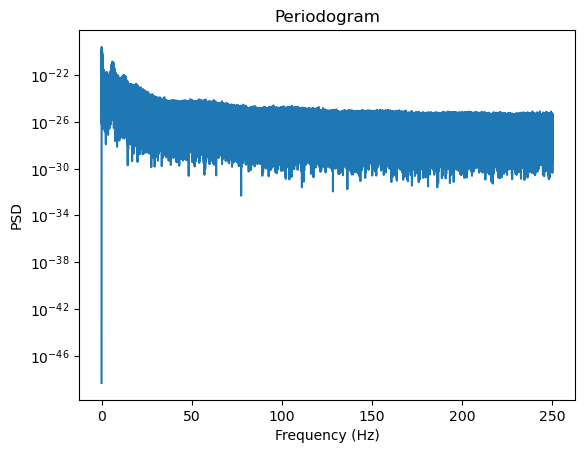

In [13]:
from scipy.signal import periodogram
fs = 500.
t=np.linspace(0,sim_length, int(fs*sim_length))
frequencies, powers = periodogram(averaged, fs)
# Plotting the periodogram
plt.semilogy(frequencies, powers)
plt.title('Periodogram')
plt.xlabel('Frequency (Hz)')
plt.ylabel('PSD')
plt.show()


from scipy.stats import pearsonr
from scipy.optimize import curve_fit
print(len(inter_event_intervals))
print(len(peaks))


# Pearson correlation
corr, p_vals = pearsonr(peaks[1:], inter_event_intervals)
print(f'Pearson correlation coefficient: {corr:.3f}')

# Define the exponential function y = a * exp(b * x)
def exp_func(x, a, b, c):
    return a * (1 -  np.exp(-b * x)) + c

# Fit the exponential function to the data
params, _ = curve_fit(exp_func, peaks[1:], inter_event_intervals, p0=(1, 0.1, 0.))

# Generate values for the fitted curve
x_fit = np.linspace(min(peaks), max(peaks), 100)  # Smooth curve
y_fit = exp_func(x_fit, *params)

# Scatter plot of the data
plt.scatter(peaks[1:], inter_event_intervals,  color="black")

# Plot the exponential fit
plt.plot(x_fit, y_fit, color="red", label=f"Exponential Fit (r={corr:.2f})")

# Labels and title
plt.xlabel("Peaks")
plt.ylabel("Inter-Event Intervals")
plt.title("Pearson Correlation: Peaks vs. Previous Inter-Event Intervals")
plt.legend()
plt.show()

WARNING    /tmp/ipykernel_5122/1548813595.py:6: RuntimeWarning: overflow encountered in exp
  return a * (1 -  np.exp(-b * x)) + c
 [py.warnings]
WARNING    /tmp/ipykernel_5122/1548813595.py:17: OptimizeWarning: Covariance of the parameters could not be estimated
  params, _ = curve_fit(exp_func, x_data, y_data, p0=(1, 0.01, 0.0))
 [py.warnings]
WARNING    /tmp/ipykernel_5122/1548813595.py:6: RuntimeWarning: overflow encountered in multiply
  return a * (1 -  np.exp(-b * x)) + c
 [py.warnings]


Pearson correlation coefficient: 0.696 with p-value: 0.000000000000
Pearson correlation coefficient: 0.004 with p-value: 0.889254867622


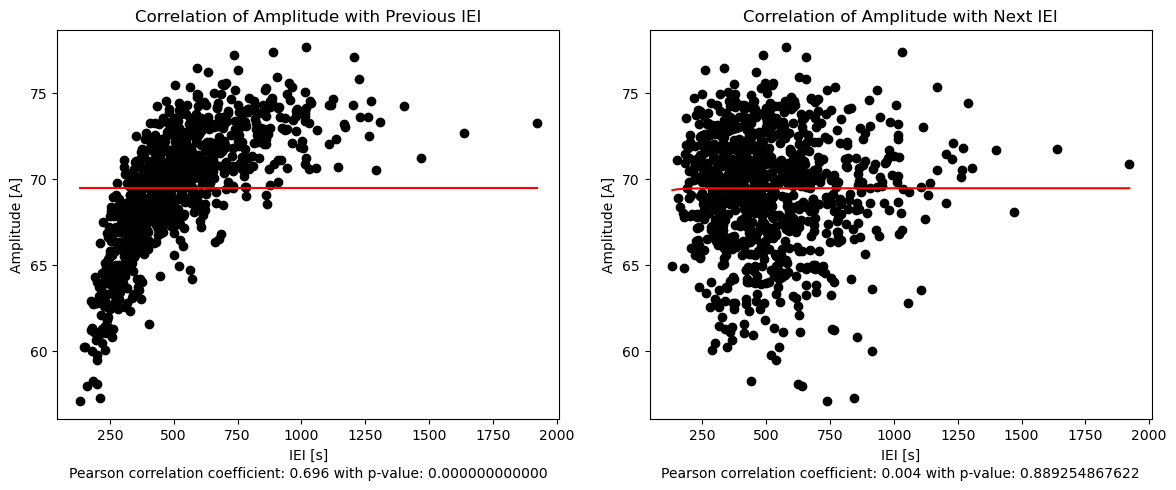

In [14]:
from scipy.stats import pearsonr
from scipy.optimize import curve_fit

# Define the exponential function: y = a * exp(b * x)
def exp_func(x, a, b, c):
    return a * (1 -  np.exp(-b * x)) + c
    #return -a * x  ** 2 + b

# Function to plot correlation and exponential fit
def plot_correlation(ax, x_data, y_data, title):

    # Pearson correlation
    corr, p = pearsonr(x_data, y_data)
    print(f'Pearson correlation coefficient: {corr:.3f} with p-value: {p:.12f}')

    # Fit exponential function
    params, _ = curve_fit(exp_func, x_data, y_data, p0=(1, 0.01, 0.0))

    # Generate smooth values for the fitted curve
    x_fit = np.linspace(min(x_data), max(x_data), 1000)
    y_fit = exp_func(x_fit, *params)

    # Scatter plot
    ax.scatter(x_data, y_data, color="black")

    # Plot exponential fit
    ax.plot(x_fit, y_fit, color="red")

    # Labels and title
    ax.set_xlabel("IEI [s]")
    ax.set_ylabel("Amplitude [A]")
    ax.set_title(title)
    ax.text(0.5, -0.15, f'Pearson correlation coefficient: {corr:.3f} with p-value: {p:.12f}', transform=ax.transAxes, fontsize=10, ha='center')
    #ax.legend()

# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# First subplot: peaks[1:]
plot_correlation(axes[0], inter_event_intervals, peaks[1:]*10**12, "Correlation of Amplitude with Previous IEI")

# Second subplot: peaks[:-2]
plot_correlation(axes[1], inter_event_intervals, peaks[:-1]*10**12, "Correlation of Amplitude with Next IEI")

plt.tight_layout()
plt.show()


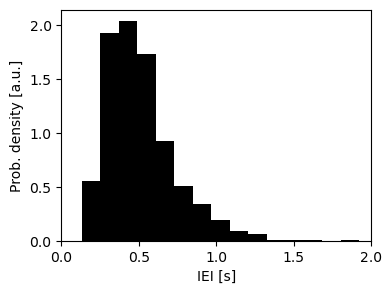

In [15]:
# Convert to seconds
inter_event_intervals = np.array(inter_event_intervals) / 1000  

# Plot histogram with probability density
plt.figure(figsize=(4, 3))
plt.hist(inter_event_intervals, bins=15, density=True, color='black', alpha=1)

# Label axes
plt.xlabel("IEI [s]")
plt.ylabel("Prob. density [a.u.]")

# Set x-axis limits to match the example
plt.xlim(0, 2)

# Display the plot
plt.show()

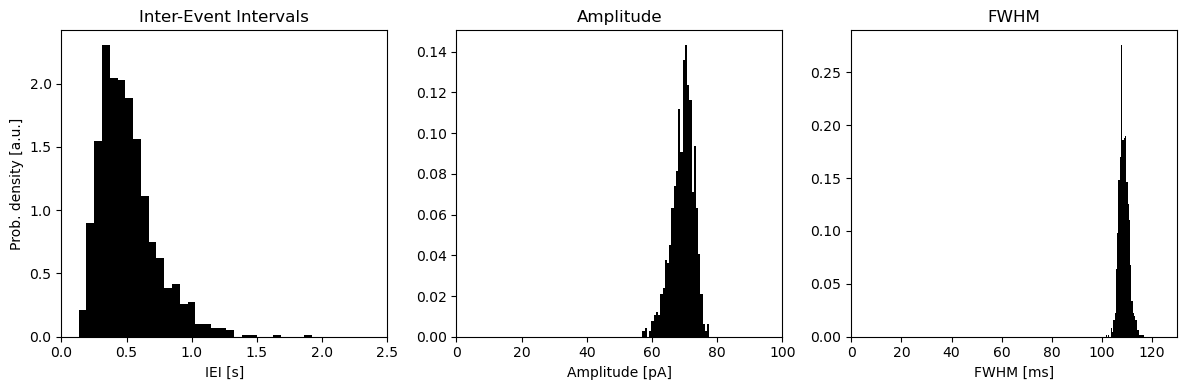

In [16]:
#print(event_boundaries)
fwhm = [(event_boundaries[i][1]-event_boundaries[i][0])*delta_t for i in range(0,len(event_boundaries))]
#print(fwhm)
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

# Histogram for inter_event_intervals
axes[0].hist(inter_event_intervals, bins=30, density=True, color='black', alpha=1)
axes[0].set_xlabel("IEI [s]")
#axes[0].set_xlim(0, 1)
axes[0].set_title("Inter-Event Intervals")
axes[0].set_xlim(0,2.5)

# Histogram for peaks
axes[1].hist(peaks*10**12, bins=30, density=True, color='black', alpha=1)
axes[1].set_xlabel("Amplitude [pA]")
#axes[1].set_xlim(min(peaks), max(peaks))
axes[1].set_title("Amplitude")
axes[1].set_xlim(0,100)

# Histogram for fwhm
axes[2].hist(fwhm, bins=30, density=True, color='black', alpha=1)
axes[2].set_xlabel("FWHM [ms]")
#axes[2].set_xlim(min(fwhm), max(fwhm))
axes[2].set_title("FWHM")
axes[2].set_xlim(0,130)
# Shared y-axis label
axes[0].set_ylabel("Prob. density [a.u.]")

# Adjust layout
plt.tight_layout()
plt.show()
